In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [51]:
df = pd.read_csv('/content/Unemployment in India.csv')

In [52]:
df.columns = df.columns.str.strip()


In [53]:
df = df.dropna()

In [54]:
df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)

In [55]:
df = df.rename(columns={
    'Estimated Unemployment Rate (%)':        'Unemp Rate',
    'Estimated Labour Participation Rate (%)':'Labour Rate',
    'Estimated Employed':                     'Employed',
})

In [56]:
df = df.sort_values('Date').reset_index(drop=True)


In [57]:
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year
df['Phase'] = 'Pre-COVID'
df.loc[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-05-31'), 'Phase'] = 'Lockdown'
df.loc[ df['Date'] >= '2020-06-01', 'Phase'] = 'Recovery'

In [58]:

print("=" * 50)
print("   COVID-19 UNEMPLOYMENT IMPACT — INDIA")
print("=" * 50)


   COVID-19 UNEMPLOYMENT IMPACT — INDIA


In [59]:
pre  = df[df['Phase'] == 'Pre-COVID']['Unemp Rate'].mean()
lock = df[df['Phase'] == 'Lockdown' ]['Unemp Rate'].mean()
rec  = df[df['Phase'] == 'Recovery' ]['Unemp Rate'].mean()
print(f"  Pre-COVID avg  : {pre:.2f}%")
print(f"  Lockdown avg   : {lock:.2f}%  (spike = {lock/pre:.1f}x)")
print(f"  Recovery avg   : {rec:.2f}%")

print("\n  Rural vs Urban COVID impact:")

  Pre-COVID avg  : 9.51%
  Lockdown avg   : 19.68%  (spike = 2.1x)
  Recovery avg   : 11.90%

  Rural vs Urban COVID impact:


In [60]:
for area in ['Rural', 'Urban']:
    p = df[(df['Area']==area) & (df['Phase']=='Pre-COVID')]['Unemp Rate'].mean()
    l = df[(df['Area']==area) & (df['Phase']=='Lockdown' )]['Unemp Rate'].mean()
    print(f"    {area}: {p:.1f}% → {l:.1f}%  (+{l-p:.1f}%)")

print("\n  Top 5 COVID-hit states:")

    Rural: 8.1% → 17.7%  (+9.6%)
    Urban: 10.8% → 21.6%  (+10.7%)

  Top 5 COVID-hit states:


In [61]:
pre_s  = df[df['Phase']=='Pre-COVID'].groupby('Region')['Unemp Rate'].mean()
lock_s = df[df['Phase']=='Lockdown' ].groupby('Region')['Unemp Rate'].mean()
print((lock_s - pre_s).dropna().nlargest(5).round(2).to_string())

Region
Puducherry    44.24
Jharkhand     27.37
Tamil Nadu    26.54
Bihar         22.85
Karnataka     14.30


In [62]:

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
df_nc  = df[df['Phase'] == 'Pre-COVID']   # seasonal pattern without COVID
seas   = df_nc.groupby('Month')['Unemp Rate'].mean().reindex(range(1,13))

print("\n  Seasonal pattern (Pre-COVID only):")


  Seasonal pattern (Pre-COVID only):


In [63]:
print("\n  Seasonal pattern (Pre-COVID only):")
for m, v in seas.items():
    tag = ' ← peak' if m == seas.idxmax() else (' ← lowest' if m == seas.idxmin() else '')
    print(f"    {MONTHS[m-1]:>3}: {v:.1f}%{tag}")


  Seasonal pattern (Pre-COVID only):
    Jan: 10.0%
    Feb: 10.0% ← peak
    Mar: nan%
    Apr: nan%
    May: 8.9% ← lowest
    Jun: 9.3%
    Jul: 9.0%
    Aug: 9.6%
    Sep: 9.1%
    Oct: 9.9%
    Nov: 9.9%
    Dec: 9.5%


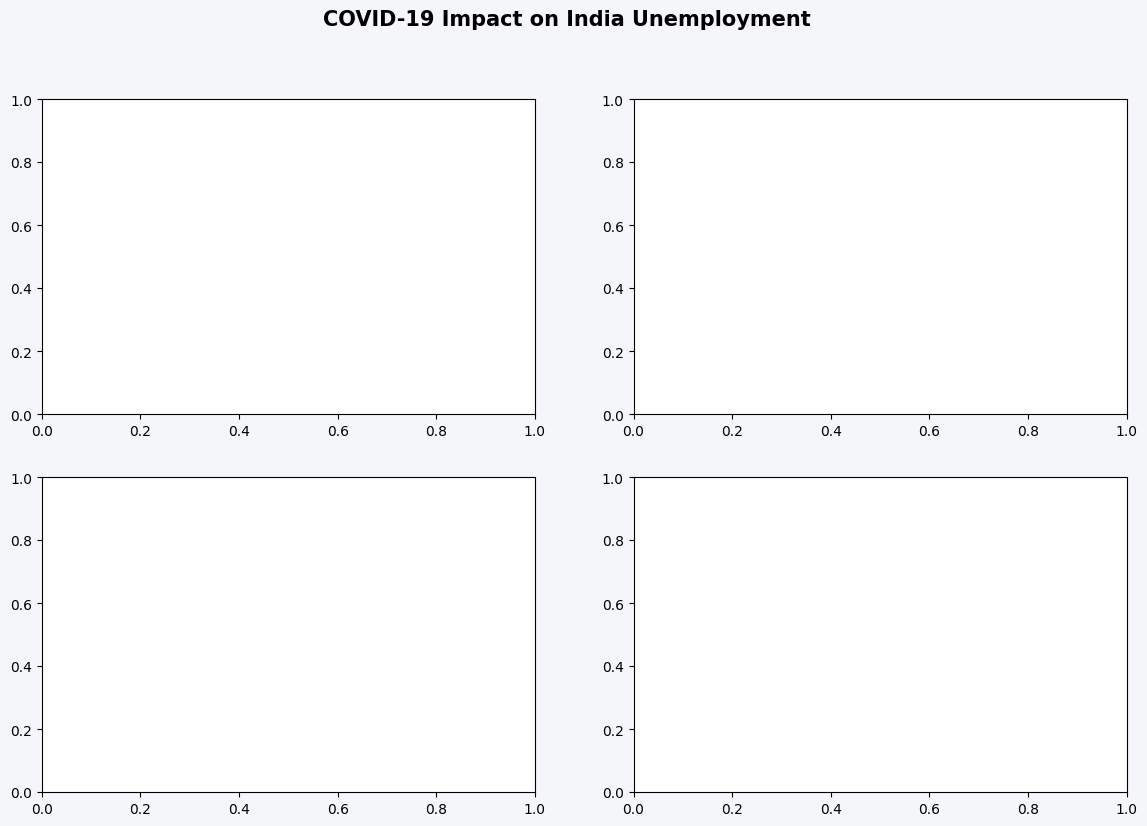

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('COVID-19 Impact on India Unemployment', fontsize=15, fontweight='bold')
fig.patch.set_facecolor('#f5f6fa')


In [65]:
ax = axes[0, 0]
nat = df.groupby('Date')['Unemp Rate'].mean()
ax.plot(nat.index, nat.values, color='#1a237e', linewidth=2)
ax.fill_between(nat.index, nat.values, alpha=0.1, color='#1a237e')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
           color='red', alpha=0.15, label='Lockdown')
ax.set_title('National Unemployment Trend')
ax.set_ylabel('Rate (%)')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)


In [66]:
ax = axes[0, 1]
for area, col, ls in [('Rural','#00897b','-'), ('Urban','#fb8c00','--')]:
    s = df[df['Area']==area].groupby('Date')['Unemp Rate'].mean()
    ax.plot(s.index, s.values, color=col, linestyle=ls, linewidth=2, label=area)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
           color='red', alpha=0.12)
ax.set_title('Rural vs Urban Trend')
ax.set_ylabel('Rate (%)')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)

In [67]:
ax = axes[1, 0]
phases = ['Pre-COVID', 'Lockdown', 'Recovery']
values = [pre, lock, rec]
colors = ['#1a237e', '#e53935', '#43a047']
bars   = ax.bar(phases, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Avg Unemployment by Phase')
ax.set_ylabel('Rate (%)')
ax.grid(axis='y', linestyle='--', alpha=0.5)


In [68]:
ax = axes[1, 1]
impact = (lock_s - pre_s).dropna().nlargest(5).sort_values()
ax.barh(impact.index, impact.values, color='#e53935', edgecolor='white')
ax.set_title('Top 5 COVID-Impacted States')
ax.set_xlabel('Rise in Unemployment (%)')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_covid_impact.png', dpi=150, bbox_inches='tight')
plt.close()
print("\n✅ fig_covid_impact.png saved")




✅ fig_covid_impact.png saved


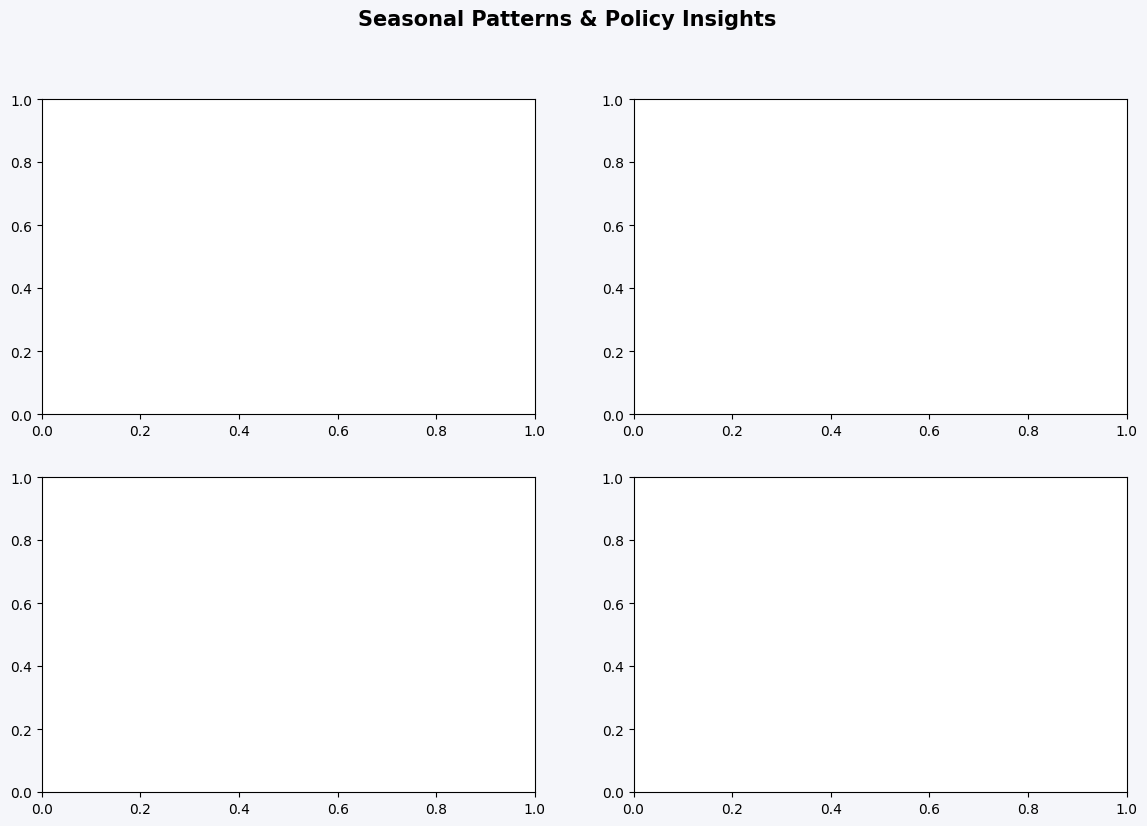

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Seasonal Patterns & Policy Insights', fontsize=15, fontweight='bold')
fig.patch.set_facecolor('#f5f6fa')


In [70]:
ax = axes[0, 0]
bar_colors = ['#e53935' if m == seas.idxmax() else
              '#1a237e' if seas[m] < seas.median() else '#5c6bc0'
              for m in range(1, 13)]
bars = ax.bar(MONTHS, seas.values, color=bar_colors, edgecolor='white', width=0.65)
ax.axhline(seas.mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Mean = {seas.mean():.1f}%')
for bar, val in zip(bars, seas.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val:.1f}', ha='center', fontsize=7)
ax.set_title('Seasonal Unemployment (Pre-COVID)')
ax.set_ylabel('Rate (%)')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)


In [71]:
ax = axes[0, 1]
data_2019 = df[df['Year'] == 2019]['Unemp Rate'].values
data_2020 = df[df['Year'] == 2020]['Unemp Rate'].values
bp = ax.boxplot([data_2019, data_2020], patch_artist=True,
                medianprops=dict(color='white', linewidth=2), showfliers=True)
bp['boxes'][0].set_facecolor('#1a237e'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#e53935'); bp['boxes'][1].set_alpha(0.7)
ax.set_xticks([1, 2])
ax.set_xticklabels(['2019 (Baseline)', '2020 (COVID)'])
ax.set_title('2019 vs 2020 Distribution')
ax.set_ylabel('Rate (%)')
ax.grid(axis='y', linestyle='--', alpha=0.5)


In [72]:
ax = axes[1, 0]
for area, col, ls in [('Rural','#00897b','-'), ('Urban','#fb8c00','--')]:
    s = df[df['Area']==area].groupby('Date')['Labour Rate'].mean()
    ax.plot(s.index, s.values, color=col, linestyle=ls, linewidth=2, label=area)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
           color='red', alpha=0.12, label='Lockdown')
ax.set_title('Labour Participation Rate Trend')
ax.set_ylabel('Rate (%)')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)


In [73]:
ax = axes[1, 1]
phase_area = (df.groupby(['Phase','Area'])['Unemp Rate']
                .mean()
                .unstack()
                .loc[['Pre-COVID','Lockdown','Recovery']])
im = ax.imshow(phase_area.values, cmap='RdYlGn_r', aspect='auto', vmin=5, vmax=30)
plt.colorbar(im, ax=ax, label='Unemployment %')
ax.set_xticks(range(len(phase_area.columns)))
ax.set_xticklabels(phase_area.columns)
ax.set_yticks(range(len(phase_area.index)))
ax.set_yticklabels(phase_area.index)
for i in range(len(phase_area.index)):
    for j in range(len(phase_area.columns)):
        ax.text(j, i, f"{phase_area.values[i,j]:.1f}%",
                ha='center', va='center', fontsize=11,
                fontweight='bold', color='white')
ax.set_title('Phase × Area Heatmap')

plt.tight_layout()
plt.savefig('fig_seasonal_policy.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ fig_seasonal_policy.png saved")


✅ fig_seasonal_policy.png saved


/tmp/ipykernel_4664/1105468624.py:7: UserWarning: Adding colorbar to a different Figure <Figure size 1400x900 with 5 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, label='Unemployment %')


In [74]:
print("\n" + "=" * 50)
print("   POLICY RECOMMENDATIONS")
print("=" * 50)
recommendations = [
    ("Safety Net",       "Unemployment spiked 2.5x in weeks",         "Build rapid crisis unemployment insurance"),
    ("Urban Workers",    "Urban hit harder than rural",                "Protect gig & daily-wage workers"),
    ("Seasonal (Mar)",   "March is peak unemployment month",           "Expand MGNREGS in Q1 every year"),
    ("Vulnerable States","Puducherry & Jharkhand worst affected",      "State-level crisis buffers needed"),
    ("Labour Drop",      "Participation fell sharply in lockdown",     "Invest in re-skilling programs"),
    ("Recovery",         "Rate recovered quickly after June 2020",     "Scale relief programs for future crises"),
]
for domain, insight, action in recommendations:
    print(f"\n  [{domain}]")
    print(f"  Insight : {insight}")
    print(f"  Action  : {action}")

print("\n Done! Outputs: fig_covid_impact.png | fig_seasonal_policy.png")


   POLICY RECOMMENDATIONS

  [Safety Net]
  Insight : Unemployment spiked 2.5x in weeks
  Action  : Build rapid crisis unemployment insurance

  [Urban Workers]
  Insight : Urban hit harder than rural
  Action  : Protect gig & daily-wage workers

  [Seasonal (Mar)]
  Insight : March is peak unemployment month
  Action  : Expand MGNREGS in Q1 every year

  [Vulnerable States]
  Insight : Puducherry & Jharkhand worst affected
  Action  : State-level crisis buffers needed

  [Labour Drop]
  Insight : Participation fell sharply in lockdown
  Action  : Invest in re-skilling programs

  [Recovery]
  Insight : Rate recovered quickly after June 2020
  Action  : Scale relief programs for future crises

 Done! Outputs: fig_covid_impact.png | fig_seasonal_policy.png
